In [167]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import pandas as pd
spark = SparkSession.builder.appName("modelling").config("spark.driver.memory", "12g").getOrCreate()

In [168]:
yellow_taxi_data = spark.read.parquet('cleaned_data/yellow_data.parquet')
yellow_taxi_data.show(1)

+-------------------+------------+------------+-------+
|               date|PULocationID|total_amount|Borough|
+-------------------+------------+------------+-------+
|2023-05-01 00:42:49|         138|       57.15| Queens|
+-------------------+------------+------------+-------+
only showing top 1 row


In [169]:
from utils import add_stations
# aggregate to daily
yellow_taxi_daily_earnings = (
    yellow_taxi_data
    .withColumn("date", F.to_date("date"))
    .groupBy("date", "PULocationID", 'Borough')
    .agg(F.sum("total_amount").alias("daily_total_amount"))
    .orderBy("date")
)
yellow_taxi_daily_earnings = add_stations(yellow_taxi_daily_earnings, spark)

residential_data = spark.read.csv('cleaned_data/residential_data.csv', header=True, inferSchema=True)
residential_data = residential_data.withColumn("residential_density", F.col("TotalResidentialUnits") / F.col("TotalNumBldgs"))
residential_data = residential_data.select('LocationID', 'residential_density')
training_data = yellow_taxi_daily_earnings.join(residential_data, yellow_taxi_daily_earnings.PULocationID == residential_data.LocationID, 'left').drop('LocationID')

# drop rows where residential_density is null
print('Shape', training_data.count(), ',', len(training_data.columns))
training_data.show(2)

Shape 262332 , 6


+----------+------------+---------+------------------+------------+-------------------+
|      date|PULocationID|  Borough|daily_total_amount|num_stations|residential_density|
+----------+------------+---------+------------------+------------+-------------------+
|2023-05-01|         165| Brooklyn|            128.86|           3| 2.4132334581772783|
|2023-05-02|          79|Manhattan| 36476.00999999998|           2| 16.148442272449604|
+----------+------------+---------+------------------+------------+-------------------+
only showing top 2 rows


In [170]:
# remove all areas that have NULL residential_density except with PULocationID 1, 132 or 138
training_data = training_data.filter(~((F.col('residential_density').isNull()) & (~F.col('PULocationID').isin([1, 132, 138]))))
# create a new column called isAirport that is 1 if PULocationID is 132, 1 or 138, else 0
training_data = training_data.withColumn('isAirport', F.when(F.col('PULocationID').isin([132, 1, 138]), 1).otherwise(0))

# replace null values in residential_density with 0
training_data = training_data.fillna({'residential_density': 0})
print('Shape', training_data.count(), ',', len(training_data.columns))

Shape 252380 , 7


In [171]:
fhvhv_taxi_data = spark.read.parquet('cleaned_data/fhvhv_data.parquet')
fhvhv_taxi_data = fhvhv_taxi_data.withColumn("date", F.to_date("date"))
fhvhv_trip_volume = (
    fhvhv_taxi_data
    .groupBy("date", "PULocationID")
    .agg(F.count("*").alias("daily_trip_volume"))
    .orderBy("date")
)
fhvhv_taxi_data.show()

+----------+------------+
|      date|PULocationID|
+----------+------------+
|2023-03-01|         114|
|2023-03-01|          79|
|2023-03-01|         113|
|2023-03-01|         229|
|2023-03-01|         144|
|2023-03-01|           7|
|2023-03-01|         255|
|2023-03-01|         255|
|2023-03-01|          80|
|2023-03-01|         255|
|2023-03-01|          80|
|2023-03-01|         255|
|2023-03-01|         231|
|2023-03-01|         229|
|2023-03-01|          36|
|2023-03-01|         112|
|2023-03-01|         141|
|2023-03-01|         161|
|2023-03-01|          75|
|2023-03-01|         139|
+----------+------------+
only showing top 20 rows


In [172]:
training_data = training_data.join(
    fhvhv_trip_volume,
    on=["date", "PULocationID"],
    how='inner'
)
print('Shape', training_data.count(), ',', len(training_data.columns))
training_data.show()

Shape 252103 , 8


+----------+------------+---------+------------------+------------+-------------------+---------+-----------------+
|      date|PULocationID|  Borough|daily_total_amount|num_stations|residential_density|isAirport|daily_trip_volume|
+----------+------------+---------+------------------+------------+-------------------+---------+-----------------+
|2023-01-01|          11| Brooklyn|              42.6|           0| 2.4930684874818954|        0|              703|
|2023-01-01|          24|Manhattan|3790.2100000000014|           1|  25.82941176470588|        0|              906|
|2023-01-01|          91| Brooklyn|              54.0|           0| 1.4156811499509965|        0|             3037|
|2023-01-01|         123| Brooklyn|             43.65|           1|  2.507860262008734|        0|             1721|
|2023-01-01|         137|Manhattan| 20404.77999999995|           0| 35.746736292428196|        0|             3458|
|2023-01-01|         174|    Bronx|              35.4|           3|  16.

In [173]:
training_data_final = training_data
training_data_final = training_data_final.withColumn("log_daily_total_amount", F.log1p("daily_total_amount"))
training_data_final = training_data_final.withColumn("log_daily_trip_volume", F.log1p("daily_trip_volume"))
training_data_final = training_data_final.withColumn("has_station", F.when(F.col("num_stations") > 0, 1).otherwise(0))
# add month and day of week columns
training_data_final = training_data_final.withColumn("day_of_week", F.dayofweek("date"))
X_train = training_data_final.drop('daily_total_amount', 'daily_trip_volume', 'date', 'num_stations', 'PULocationID')
X_train.show()

+---------+-------------------+---------+----------------------+---------------------+-----------+-----------+
|  Borough|residential_density|isAirport|log_daily_total_amount|log_daily_trip_volume|has_station|day_of_week|
+---------+-------------------+---------+----------------------+---------------------+-----------+-----------+
| Brooklyn| 2.4930684874818954|        0|     3.775057150354989|    6.556778356158042|          0|          1|
|Manhattan|  25.82941176470588|        0|     8.240440508337176|    6.810142450115136|          1|          1|
| Brooklyn| 1.4156811499509965|        0|     4.007333185232471|    8.018954683155718|          0|          1|
| Brooklyn|  2.507860262008734|        0|     3.798854307322508|    7.451241684987676|          1|          1|
|Manhattan| 35.746736292428196|        0|      9.92357347303433|    8.148734808937169|          0|          1|
|    Bronx|  16.83679833679834|        0|     3.594568774642695|    7.845024417241484|          1|          1|
|

In [174]:
X_train_pd = X_train.toPandas()

<Axes: >

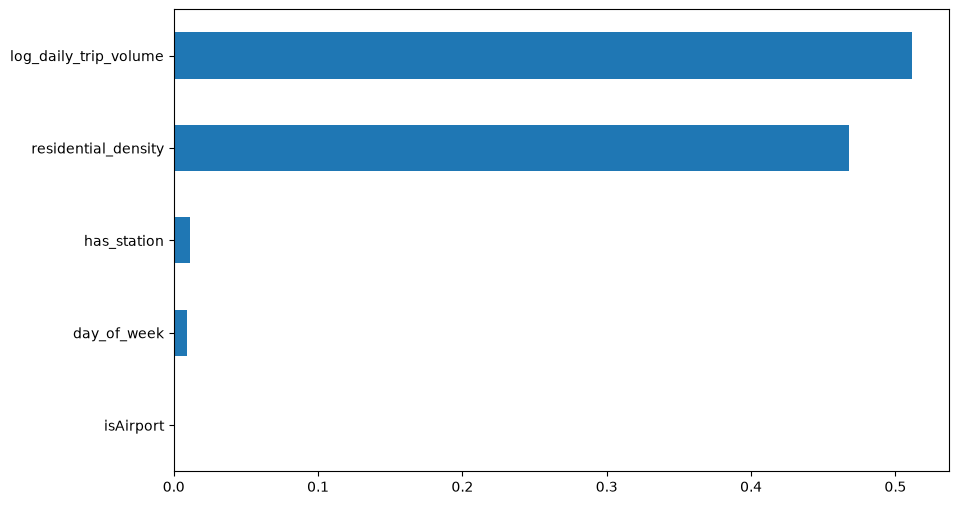

In [175]:
from sklearn.ensemble import RandomForestRegressor
X = X_train_pd.loc[X_train_pd['Borough'] == 'Manhattan']
X.drop(['Borough'], axis=1, inplace=True)
y = X.pop('log_daily_total_amount')
model = RandomForestRegressor()
model.fit(X, y)

# make a horizontal bar plot
plt.figure(figsize=(10, 6))
feature_importances = pd.Series(model.feature_importances_, index=X.columns)
feature_importances.sort_values().plot(kind='barh')

In [176]:
# print R squared score
r_squared = model.score(X, y)
print(f'R squared score: {r_squared:.4f}')

R squared score: 0.9924


In [177]:
# Path containing all Parquet files
input_path_fhvhv = "data/year-2026-fhvhv"
input_path_yellow = "data/year-2026-yellow"

# Read and concatenate all Parquet files into a single DataFrame
data_2026_raw = spark.read.parquet(input_path_fhvhv)
data_2026_raw = data_2026_raw.select('pickup_datetime', 'PULocationID')

# calculate daily trip volume per PULocationID
data_2026_raw = (
    data_2026_raw
    .withColumn("date", F.to_date("pickup_datetime"))
    .groupBy("date", "PULocationID")
    .agg(F.count("*").alias("daily_trip_volume"))
    .orderBy("date")
)

print(f"Number of rows: {data_2026_raw.count()}")
print(f"Number of columns: {len(data_2026_raw.columns)}")

Number of rows: 39070
Number of columns: 3


In [178]:
yellow_taxi_data_2026 = spark.read.parquet(input_path_yellow)
yellow_taxi_data_2026 = yellow_taxi_data_2026.withColumn("date", F.to_date("tpep_pickup_datetime"))
yellow_taxi_daily_earnings_2026 = (
    yellow_taxi_data_2026
    .groupBy("date", "PULocationID")
    .agg(F.sum("total_amount").alias("daily_total_amount"))
    .orderBy("date")
)
yellow_taxi_daily_earnings_2026 = add_stations(yellow_taxi_daily_earnings_2026, spark)
# add residential density by using training_data as a lookup
yellow_taxi_daily_earnings_2026 = yellow_taxi_daily_earnings_2026.join(
    residential_data,
    yellow_taxi_daily_earnings_2026.PULocationID == residential_data.LocationID,
    'left'
).drop('LocationID')
# add isAirport column
yellow_taxi_daily_earnings_2026 = yellow_taxi_daily_earnings_2026.withColumn('isAirport', F.when(F.col('PULocationID').isin([132, 1, 138]), 1).otherwise(0))
# remove all areas that have NULL residential_density except with PULocationID 1, 132 or 138
yellow_taxi_daily_earnings_2026 = yellow_taxi_daily_earnings_2026.filter(~((F.col('residential_density').isNull()) & (~F.col('PULocationID').isin([1, 132, 138]))))
# replace null values in residential_density with 0
yellow_taxi_daily_earnings_2026 = yellow_taxi_daily_earnings_2026.fillna({'residential_density': 0})
# add the Borough column by using training_data as a lookup
yellow_taxi_daily_earnings_2026 = yellow_taxi_daily_earnings_2026.join(
    training_data.select('PULocationID', 'Borough').distinct(),
    on='PULocationID',
    how='left'
)
# add trip volume
test_data = yellow_taxi_daily_earnings_2026.join(
    data_2026_raw,
    on=["date", "PULocationID"],
    how='inner'
)
# add log columns
test_data = test_data.withColumn("log_daily_total_amount", F.log1p("daily_total_amount"))
test_data = test_data.withColumn("log_daily_trip_volume", F.log1p("daily_trip_volume"))
test_data = test_data.withColumn("has_station", F.when(F.col("num_stations") > 0, 1).otherwise(0))
# add month and day of week columns
test_data = test_data.withColumn("day_of_week", F.dayofweek("date"))
# drop unnecessary columns
test_data = test_data.drop('daily_total_amount', 'daily_trip_volume', 'date', 'num_stations', 'PULocationID')
test_data.show(2)

+-------------------+---------+--------+----------------------+---------------------+-----------+-----------+
|residential_density|isAirport| Borough|log_daily_total_amount|log_daily_trip_volume|has_station|day_of_week|
+-------------------+---------+--------+----------------------+---------------------+-----------+-----------+
|  2.588637266587207|        0|Brooklyn|     6.262121257090876|    7.404887575616125|          1|          7|
|  2.588637266587207|        0|Brooklyn|    7.4497248557411115|    8.446985296372741|          1|          3|
+-------------------+---------+--------+----------------------+---------------------+-----------+-----------+
only showing top 2 rows


In [179]:
import numpy as np
X_test = test_data.toPandas()
X_test = X_test.loc[X_test['Borough'] == 'Manhattan']
X_test.drop(['Borough'], axis=1, inplace=True)
y_test = X_test.pop('log_daily_total_amount')
predictions = model.predict(X_test)

# evaluate the model using RMSE, R squared and MAE
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)

print(f"RMSE: {rmse}")
print(f"R²: {r2}")
print(f"MAE: {mae}")

RMSE: 0.9337032488452371
R²: 0.41549647099064435
MAE: 0.7631413050850625


Training set size: 75361 records
Features: ['residential_density', 'isAirport', 'log_daily_trip_volume', 'has_station', 'day_of_week']

Running GridSearchCV with 5-fold cross-validation...
Fitting 5 folds for each of 6 candidates, totalling 30 fits

BEST HYPERPARAMETERS
Best CV R² Score: 0.9593

  max_depth: 20
  n_estimators: 100

FEATURE IMPORTANCES



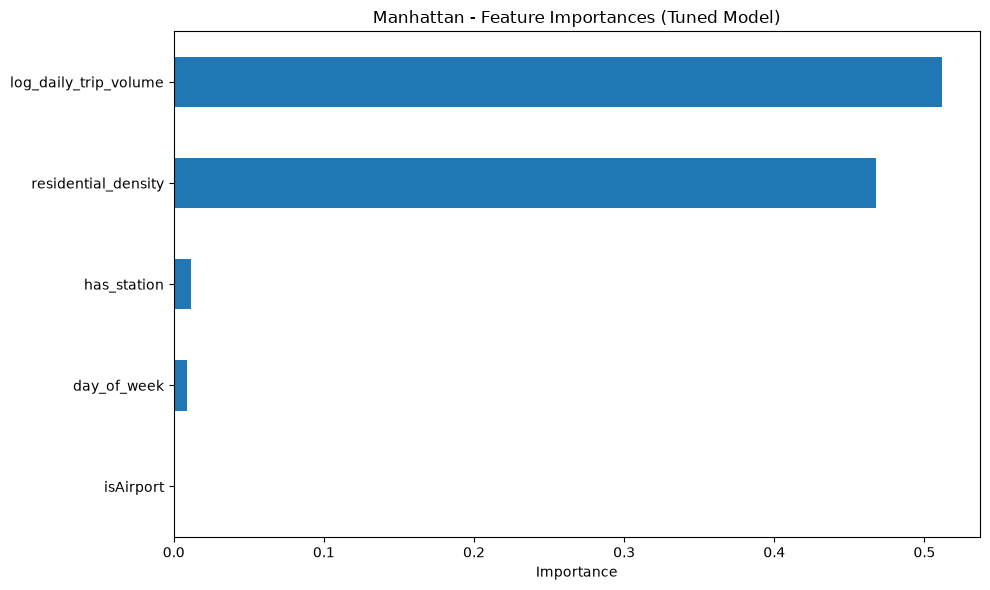

log_daily_trip_volume    0.511463
residential_density      0.467831
has_station              0.011800
day_of_week              0.008906
isAirport                0.000000
dtype: float64


In [180]:
from sklearn.model_selection import GridSearchCV

# Filter to Manhattan and prepare data
X = X_train_pd.loc[X_train_pd['Borough'] == 'Manhattan'].copy()
X.drop(['Borough'], axis=1, inplace=True)
y = X.pop('log_daily_total_amount')

print(f"Training set size: {len(X)} records")
print(f"Features: {X.columns.tolist()}\n")

# Define hyperparameter grid
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, 20],
}

# GridSearchCV
print("Running GridSearchCV with 5-fold cross-validation...")
grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X, y)

# Best model and parameters
print(f"\n{'='*70}")
print("BEST HYPERPARAMETERS")
print(f"{'='*70}")
print(f"Best CV R² Score: {grid_search.best_score_:.4f}\n")

for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

# Train final model with best params
best_model = grid_search.best_estimator_

# Show feature importances
print(f"\n{'='*70}")
print("FEATURE IMPORTANCES")
print(f"{'='*70}\n")

plt.figure(figsize=(10, 6))
feature_importances = pd.Series(best_model.feature_importances_, index=X.columns)
feature_importances.sort_values().plot(kind='barh')
plt.xlabel('Importance')
plt.title('Manhattan - Feature Importances (Tuned Model)')
plt.tight_layout()
plt.show()

print(feature_importances.sort_values(ascending=False))

In [181]:
predictions = best_model.predict(X_test)
# evaluate the model using RMSE, R squared and MAE
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")
print(f"MAE: {mae:.4f}")

RMSE: 0.9381
R²: 0.4100
MAE: 0.7599
